In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("SpambaseClassification") \
    .getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/13 07:23:01 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
names_file = "/Users/tcbailey/Documents/imse785/projects/project5/inputs/spambase/spambase.names"

column_names = []

with open(names_file, "r") as f:
    for line in f:
        line = line.strip()

        if (
            ":" in line
            and line.startswith((
                "word_freq_",
                "char_freq_",
                "capital_run_length"
            ))
        ):
            column_names.append(line.split(":")[0])

# Add the target column
column_names.append("spam")

print(f"Number of columns found: {len(column_names)}")

Number of columns found: 58


In [3]:
# Load spambase.data (no header, comma-separated values) into a DataFrame
spambase_df = spark.read.csv("/Users/tcbailey/Documents/imse785/projects/project5/inputs/spambase/spambase.data", \
    header=False, inferSchema=True).toDF(*column_names)

print("Rows, Columns:", spambase_df.count(), len(spambase_df.columns))
spambase_df.show(5)

Rows, Columns: 4601 58
+--------------+-----------------+-------------+------------+-------------+--------------+----------------+------------------+---------------+--------------+-----------------+--------------+----------------+----------------+-------------------+--------------+------------------+---------------+-------------+----------------+--------------+--------------+-------------+---------------+------------+-------------+----------------+-------------+-------------+--------------+----------------+-------------+--------------+-------------+------------+--------------------+--------------+---------------+------------+----------------+------------+-----------------+------------------+-----------------+------------+-------------+---------------+--------------------+-----------+-----------+-----------+-----------+-----------+-----------+--------------------------+--------------------------+------------------------+----+
|word_freq_make|word_freq_address|word_freq_all|word_freq_3d|

26/07/13 07:23:05 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [4]:
# Q1 - Train/Test Split, Best Model per Algorithm (LR, DT, RF)
from pyspark.ml.feature import VectorAssembler
from pyspark.ml import Pipeline

feature_cols = [c for c in spambase_df.columns if c != "spam"]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

# Train/Test Split (70/30)
train_df, test_df = spambase_df.randomSplit([0.7, 0.3], seed=42)
train_df.cache()
test_df.cache()

DataFrame[word_freq_make: double, word_freq_address: double, word_freq_all: double, word_freq_3d: double, word_freq_our: double, word_freq_over: double, word_freq_remove: double, word_freq_internet: double, word_freq_order: double, word_freq_mail: double, word_freq_receive: double, word_freq_will: double, word_freq_people: double, word_freq_report: double, word_freq_addresses: double, word_freq_free: double, word_freq_business: double, word_freq_email: double, word_freq_you: double, word_freq_credit: double, word_freq_your: double, word_freq_font: double, word_freq_000: double, word_freq_money: double, word_freq_hp: double, word_freq_hpl: double, word_freq_george: double, word_freq_650: double, word_freq_lab: double, word_freq_labs: double, word_freq_telnet: double, word_freq_857: double, word_freq_data: double, word_freq_415: double, word_freq_85: double, word_freq_technology: double, word_freq_1999: double, word_freq_parts: double, word_freq_pm: double, word_freq_direct: double, word

In [5]:
# Evaluation Helper (Precison, Recall, F1)
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

def evaluate_model(predictions, label_col="spam", prediction_col="prediction"):
    evaluator_f1 = MulticlassClassificationEvaluator(
        labelCol=label_col, predictionCol=prediction_col, metricName="f1")
    evaluation_precision = MulticlassClassificationEvaluator(
        labelCol=label_col, predictionCol=prediction_col, metricName="weightedPrecision")
    evaluation_recall = MulticlassClassificationEvaluator(
        labelCol=label_col, predictionCol=prediction_col, metricName="weightedRecall")

    f1 = evaluator_f1.evaluate(predictions)
    precision = evaluation_precision.evaluate(predictions)
    recall = evaluation_recall.evaluate(predictions)

    return f1, precision, recall

In [6]:
# Logistic Regression - Grid Search (F1 criterion)
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

lr = LogisticRegression(labelCol="spam", featuresCol="features", maxIter=100)
lr_pipeline = Pipeline(stages=[assembler, lr])

lr_param_grid = (ParamGridBuilder()
    .addGrid(lr.regParam, [0.01, 0.1, 1.0])
    .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0]) # 0=L2, 1=L1
    .build())

lr_evaluator = MulticlassClassificationEvaluator(
    labelCol="spam", predictionCol="prediction", metricName="f1")

lr_cv = CrossValidator(
    estimator=lr_pipeline,
    estimatorParamMaps = lr_param_grid,
    evaluator=lr_evaluator,
    numFolds=5,
    parallelism=4
)

lr_cv_model = lr_cv.fit(train_df)
best_lr_model = lr_cv_model.bestModel

26/07/13 07:23:07 WARN BlockManager: Block rdd_31_0 already exists on this machine; not re-adding it
26/07/13 07:23:07 WARN BlockManager: Block rdd_31_0 already exists on this machine; not re-adding it
26/07/13 07:23:08 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


In [7]:
# Decision Tree - Grid Search (F1 criterion)
from pyspark.ml.classification import DecisionTreeClassifier

dt = DecisionTreeClassifier(labelCol="spam", featuresCol="features", seed=42)
dt_pipeline = Pipeline(stages=[assembler, dt])

dt_param_grid = (ParamGridBuilder()
    .addGrid(dt.maxDepth, [5, 10, 20])
    .addGrid(dt.minInstancesPerNode, [1, 5, 10])
    .build())

dt_evaluator = lr_evaluator  # Reuse the same evaluator for F1

dt_cv = CrossValidator(
    estimator=dt_pipeline,
    estimatorParamMaps = dt_param_grid,
    evaluator=dt_evaluator,
    numFolds=5,
    parallelism=4
)

dt_cv_model = dt_cv.fit(train_df)
best_dt_model = dt_cv_model.bestModel

In [8]:
# Random Forest - Grid Search (F1 criterion)
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(labelCol="spam", featuresCol="features", seed=42)
rf_pipeline = Pipeline(stages=[assembler, rf])

rf_param_grid = (ParamGridBuilder()
    .addGrid(rf.numTrees, [50, 100])
    .addGrid(rf.maxDepth, [5, 10, 20])
    .build())

rf_evaluator = lr_evaluator  # Reuse the same evaluator for F1

rf_cv = CrossValidator(
    estimator=rf_pipeline,
    estimatorParamMaps=rf_param_grid,
    evaluator=rf_evaluator,
    numFolds=5,
    parallelism=4
)

rf_cv_model = rf_cv.fit(train_df)
best_rf_model = rf_cv_model.bestModel

26/07/13 07:23:31 WARN DAGScheduler: Broadcasting large task binary with size 1069.2 KiB
26/07/13 07:23:31 WARN DAGScheduler: Broadcasting large task binary with size 1069.2 KiB
26/07/13 07:23:32 WARN DAGScheduler: Broadcasting large task binary with size 1274.7 KiB
26/07/13 07:23:32 WARN DAGScheduler: Broadcasting large task binary with size 1274.7 KiB
26/07/13 07:23:32 WARN DAGScheduler: Broadcasting large task binary with size 1482.4 KiB
26/07/13 07:23:32 WARN DAGScheduler: Broadcasting large task binary with size 1674.9 KiB
26/07/13 07:23:32 WARN DAGScheduler: Broadcasting large task binary with size 1841.5 KiB
26/07/13 07:23:32 WARN DAGScheduler: Broadcasting large task binary with size 1986.4 KiB
26/07/13 07:23:33 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/07/13 07:23:33 WARN DAGScheduler: Broadcasting large task binary with size 1150.3 KiB
26/07/13 07:23:33 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/07/13 07:23:33 WARN DAGS

In [9]:
# Evaluate Best Models (Test and All Data)

models_q1 = {
    "Logistic Regression": best_lr_model,
    "Decision Tree": best_dt_model,
    "Random Forest": best_rf_model
}

q1_results_test = []
q1_results_all = []

for name, model in models_q1.items():
    # Test set
    test_pred = model.transform(test_df)
    p, r, f1 = evaluate_model(test_pred)
    print(f"{name} on TEST:")
    print("Precision:", p, "Recall:", r, "F1:", f1)
    q1_results_test.append((name, p, r, f1))

    # All data
    all_pred = model.transform(spambase_df)
    p_all, r_all, f1_all = evaluate_model(all_pred)
    print(f"{name} on ALL DATA:")
    print("Precision:", p_all, "Recall:", r_all, "F1:", f1_all)
    q1_results_all.append((name, p_all, r_all, f1_all))

print("Q1 Test Metrics:", q1_results_test)
print(q1_results_test[0:5])
print("Q1 All Data Metrics:", q1_results_all)
print(q1_results_all[0:5])

Logistic Regression on TEST:
Precision: 0.9152732454087354 Recall: 0.915332780728136 F1: 0.9154607768469154
Logistic Regression on ALL DATA:
Precision: 0.9179846695221805 Recall: 0.9186918063983301 F1: 0.9184959791349707
Decision Tree on TEST:
Precision: 0.92308751049593 Recall: 0.9230991965711337 F1: 0.923076923076923
Decision Tree on ALL DATA:
Precision: 0.9758642334531825 Recall: 0.9758614712904454 F1: 0.9758748098239514


26/07/13 07:24:11 WARN DAGScheduler: Broadcasting large task binary with size 1844.4 KiB
26/07/13 07:24:11 WARN DAGScheduler: Broadcasting large task binary with size 1844.4 KiB
26/07/13 07:24:11 WARN DAGScheduler: Broadcasting large task binary with size 1844.4 KiB


Random Forest on TEST:
Precision: 0.9504159202972094 Recall: 0.9504748414550845 F1: 0.9504950495049505


26/07/13 07:24:11 WARN DAGScheduler: Broadcasting large task binary with size 1781.1 KiB
26/07/13 07:24:11 WARN DAGScheduler: Broadcasting large task binary with size 1781.1 KiB


Random Forest on ALL DATA:
Precision: 0.9808411618338677 Recall: 0.9809213039606497 F1: 0.9808737231036732
Q1 Test Metrics: [('Logistic Regression', 0.9152732454087354, 0.915332780728136, 0.9154607768469154), ('Decision Tree', 0.92308751049593, 0.9230991965711337, 0.923076923076923), ('Random Forest', 0.9504159202972094, 0.9504748414550845, 0.9504950495049505)]
[('Logistic Regression', 0.9152732454087354, 0.915332780728136, 0.9154607768469154), ('Decision Tree', 0.92308751049593, 0.9230991965711337, 0.923076923076923), ('Random Forest', 0.9504159202972094, 0.9504748414550845, 0.9504950495049505)]
Q1 All Data Metrics: [('Logistic Regression', 0.9179846695221805, 0.9186918063983301, 0.9184959791349707), ('Decision Tree', 0.9758642334531825, 0.9758614712904454, 0.9758748098239514), ('Random Forest', 0.9808411618338677, 0.9809213039606497, 0.9808737231036732)]
[('Logistic Regression', 0.9179846695221805, 0.9186918063983301, 0.9184959791349707), ('Decision Tree', 0.9758642334531825, 0.97586

26/07/13 07:24:11 WARN DAGScheduler: Broadcasting large task binary with size 1781.1 KiB


In [10]:
# Q2 - 5-fold CV with ROC AUC (Best Overall Model)
from pyspark.ml.evaluation import BinaryClassificationEvaluator

bin_evaluator = BinaryClassificationEvaluator(
    labelCol="spam",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

In [11]:
# Logistic Regression - CV with ROC AUC
lr = LogisticRegression(labelCol="spam", featuresCol="features", maxIter=100)
lr_pipeline_roc = Pipeline(stages=[assembler, lr])

lr_param_grid_roc = (ParamGridBuilder()
    .addGrid(lr.regParam, [0.01, 0.1, 1.0])
    .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0])
    .build())

lr_cv_roc = CrossValidator(
    estimator=lr_pipeline_roc,
    estimatorParamMaps=lr_param_grid_roc,
    evaluator=bin_evaluator,
    numFolds=5,
    parallelism=4
)

lr_cv_model_roc = lr_cv_roc.fit(train_df)
best_lr_model_roc = lr_cv_model_roc.bestModel
lr_best_roc = max(lr_cv_model_roc.avgMetrics)
print("LR best ROC AUC (CV):", lr_best_roc)

LR best ROC AUC (CV): 0.9656425806264208


In [12]:
# Decision Tree - CV with ROC AUC

dt = DecisionTreeClassifier(labelCol="spam", featuresCol="features", seed=42)
dt_pipeline_roc = Pipeline(stages=[assembler, dt])

dt_param_grid_roc = (ParamGridBuilder()
    .addGrid(dt.maxDepth, [5, 10, 20])
    .addGrid(dt.minInstancesPerNode, [1, 5, 10])
    .build())

dt_cv_roc = CrossValidator(
    estimator=dt_pipeline_roc,
    estimatorParamMaps=dt_param_grid_roc,
    evaluator=bin_evaluator,
    numFolds=5,
    parallelism=4
)

dt_cv_model_roc = dt_cv_roc.fit(train_df)
best_dt_model_roc = dt_cv_model_roc.bestModel
dt_best_roc = max(dt_cv_model_roc.avgMetrics)
print("DT best ROC AUC (CV):", dt_best_roc)

26/07/13 07:24:20 WARN BlockManager: Block rdd_13369_0 already exists on this machine; not re-adding it


DT best ROC AUC (CV): 0.9199497650186022


In [13]:
# Random Forest - CV with ROC AUC

rf = RandomForestClassifier(labelCol="spam", featuresCol="features", seed=42)
rf_pipeline_roc = Pipeline(stages=[assembler, rf])

rf_param_grid_roc = (ParamGridBuilder()
    .addGrid(rf.numTrees, [50, 100])
    .addGrid(rf.maxDepth, [5, 10, 20])
    .build())

rf_cv_roc = CrossValidator(
    estimator=rf_pipeline_roc,
    estimatorParamMaps=rf_param_grid_roc,
    evaluator=bin_evaluator,
    numFolds=5,
    parallelism=4
)

rf_cv_model_roc = rf_cv_roc.fit(train_df)
best_rf_model_roc = rf_cv_model_roc.bestModel
rf_best_roc = max(rf_cv_model_roc.avgMetrics)
print("RF best ROC AUC (CV):", rf_best_roc)

26/07/13 07:24:30 WARN DAGScheduler: Broadcasting large task binary with size 1069.2 KiB
26/07/13 07:24:30 WARN DAGScheduler: Broadcasting large task binary with size 1069.2 KiB
26/07/13 07:24:31 WARN DAGScheduler: Broadcasting large task binary with size 1274.7 KiB
26/07/13 07:24:31 WARN DAGScheduler: Broadcasting large task binary with size 1274.7 KiB
26/07/13 07:24:31 WARN DAGScheduler: Broadcasting large task binary with size 1482.4 KiB
26/07/13 07:24:31 WARN DAGScheduler: Broadcasting large task binary with size 1674.9 KiB
26/07/13 07:24:31 WARN DAGScheduler: Broadcasting large task binary with size 1841.5 KiB
26/07/13 07:24:32 WARN DAGScheduler: Broadcasting large task binary with size 1986.4 KiB
26/07/13 07:24:32 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/07/13 07:24:32 WARN DAGScheduler: Broadcasting large task binary with size 1150.3 KiB
26/07/13 07:24:32 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/07/13 07:24:32 WARN DAGS

RF best ROC AUC (CV): 0.9832565972567971


In [14]:
# Compare Algorithms and Pick Best Overall Model
roc_results = {
    "Logistic Regression": lr_best_roc,
    "Decision Tree": dt_best_roc,
    "Random Forest": rf_best_roc
}
print("ROC AUC Results:", roc_results)

# Pick best by ROC AUC
best_model_name = max(roc_results, key=roc_results.get)
best_model_roc_auc = roc_results[best_model_name]
print(f"Best Overall Model: {best_model_name} with ROC AUC: {best_model_roc_auc}")

ROC AUC Results: {'Logistic Regression': np.float64(0.9656425806264208), 'Decision Tree': np.float64(0.9199497650186022), 'Random Forest': np.float64(0.9832565972567971)}
Best Overall Model: Random Forest with ROC AUC: 0.9832565972567971


Top 10 Feature Importances:
                       feature  importance
51                 char_freq_!    0.126194
52                 char_freq_$    0.110256
6             word_freq_remove    0.086179
15              word_freq_free    0.072671
54  capital_run_length_average    0.067475
55  capital_run_length_longest    0.056039
24                word_freq_hp    0.046760
20              word_freq_your    0.042818
56    capital_run_length_total    0.037328
23             word_freq_money    0.035518


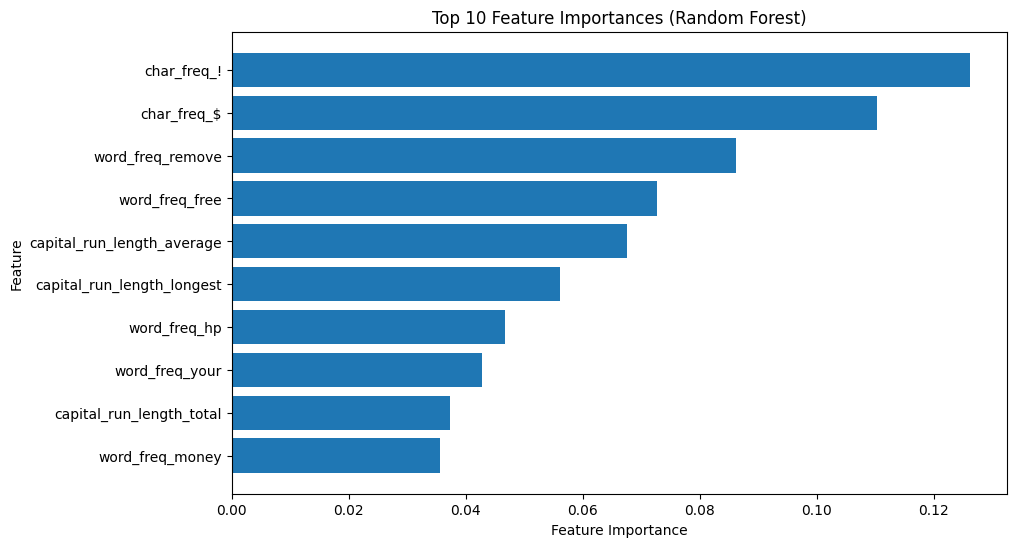

In [15]:
# Q3: Feature Importance Based on Best Model (Random Forest)
if best_model_name == "Random Forest":
    rf_model = best_rf_model_roc.stages[-1]  # Get the Random Forest model from the pipeline
    feature_importances = rf_model.featureImportances

    # Create a DataFrame for feature importances
    import pandas as pd
    feature_importance_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": feature_importances.toArray()
    }).sort_values(by="importance", ascending=False)

    print("Top 10 Feature Importances:")
    print(feature_importance_df.head(10))

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df.head(10)['feature'], feature_importance_df.head(10)['importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.show()

In [16]:
# Q5: Evaluate Best Model, Confusion Matrix
test_pred_q2 = best_rf_model_roc.transform(test_df)
precision_q2, recall_q2, f1_q2 = evaluate_model(test_pred_q2)
roc_auc_q2 = bin_evaluator.evaluate(test_pred_q2)

print("Best Q2 Model:", best_model_name)
print("Precision:", precision_q2)
print("Recall:", recall_q2)
print("F1 Score:", f1_q2)
print("ROC AUC:", roc_auc_q2)

# Confusion Matrix
from pyspark.mllib.evaluation import MulticlassMetrics
from pyspark.sql.functions import col

cm = (test_pred_q2
      .groupBy("spam", "prediction")
      .count()
      .orderBy("spam", "prediction"))

print("Confusion Matrix:")
cm.show()

26/07/13 07:25:15 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB
26/07/13 07:25:15 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB
26/07/13 07:25:15 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB
26/07/13 07:25:16 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB


Best Q2 Model: Random Forest
Precision: 0.9518811030492489
Recall: 0.9521584638586726
F1 Score: 0.952018278750952
ROC AUC: 0.9861355865648866
Confusion Matrix:


26/07/13 07:25:16 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB


+----+----------+-----+
|spam|prediction|count|
+----+----------+-----+
|   0|       0.0|  750|
|   0|       1.0|   22|
|   1|       0.0|   41|
|   1|       1.0|  500|
+----+----------+-----+



26/07/13 07:25:16 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB


In [ ]:
# Gradient Boosted Trees (GBT) - Compare to Q2 Best Model
from pyspark.ml.classification import GBTClassifier

gbt = GBTClassifier(featuresCol="features", labelCol="spam", maxIter=50, maxDepth=5, seed=42)
gbt_pipeline = Pipeline(stages=[assembler, gbt])

gbt_param_grid = (ParamGridBuilder()
    .addGrid(gbt.maxDepth, [3, 5])
    .addGrid(gbt.maxIter, [20, 50])
    .build())

gbt_cv = CrossValidator(
    estimator=gbt_pipeline,
    estimatorParamMaps=gbt_param_grid,
    evaluator=bin_evaluator,
    numFolds=5,
    parallelism=4
)

gbt_cv_model = gbt_cv.fit(train_df)
gbt_best_roc = max(gbt_cv_model.avgMetrics)
print("GBT best ROC AUC (CV):", gbt_best_roc)

# You can compare gbt_best_roc with best_roc_value from Q2
print("Q2 best ROC AUC:", best_model_roc_auc, "from model:", best_model_name)
print("GBT ROC AUC:", gbt_best_roc, " (optional comparison)")

26/07/13 07:31:32 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 125789 ms exceeds timeout 120000 ms
26/07/13 07:31:32 WARN SparkContext: Killing executors is not supported by current scheduler.
26/07/13 07:33:14 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:81)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:674)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1530)
	at o

GBT best ROC AUC (CV): 0.9799214273756871
Q2 best ROC AUC: 0.9832565972567971 from model: Random Forest
GBT ROC AUC: 0.9799214273756871  (optional comparison)


26/07/13 07:33:24 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:81)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:674)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1530)
	at org.apache.spark.executor.Executor.$anonfun$heartbeater$1(Executor.scala:483)
	at scala.runtime.java8.JFunction0$mcV$sp.apply(JFunction0$mcV$sp.scala:18)
	at org.apache.spark.util.Utils$.logUncaughtExceptions(Utils.scala:1941